<a href="https://colab.research.google.com/github/dsatish1252/sqlite-python-implementation/blob/main/Loan_Default_Risk_Prediction_Using_Machine_Learning_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np

# Reproducibility
np.random.seed(42)

# Number of records
n = 5000

# -----------------------------
# Generate Customer IDs
# -----------------------------
customer_id = [f"CUST{100001+i}" for i in range(n)]

# -----------------------------
# Generate Features
# -----------------------------
age = np.random.randint(21, 61, n)

monthly_income = np.random.randint(20000, 150001, n)

credit_score = np.random.randint(300, 851, n)

loan_amount = np.random.randint(100000, 2000001, n)

loan_tenure = np.random.choice([12, 24, 36, 48, 60], n)

existing_emi = np.random.randint(0, 40001, n)

employment_type = np.random.choice(
    ["Salaried", "Self-employed", "Business", "Unemployed"],
    n,
    p=[0.50, 0.20, 0.20, 0.10]
)

education_level = np.random.choice(
    ["Graduate", "Postgraduate", "Diploma", "School"],
    n,
    p=[0.45, 0.20, 0.20, 0.15]
)

marital_status = np.random.choice(
    ["Single", "Married"],
    n,
    p=[0.40, 0.60]
)

dependents = np.random.randint(0, 5, n)

previous_default = np.random.choice(
    ["Yes", "No"],
    n,
    p=[0.20, 0.80]
)

# -----------------------------
# Generate Target Variable
# -----------------------------

risk_score = np.zeros(n)

# Lower credit score increases risk
risk_score += np.where(credit_score < 600, 3, 0)
risk_score += np.where(credit_score < 500, 2, 0)

# Low income
risk_score += np.where(monthly_income < 35000, 2, 0)

# High loan amount
risk_score += np.where(loan_amount > 1200000, 2, 0)

# High EMI
risk_score += np.where(existing_emi > 20000, 2, 0)

# Previous default
risk_score += np.where(previous_default == "Yes", 4, 0)

# Unemployed
risk_score += np.where(employment_type == "Unemployed", 3, 0)

# Business/Self-employed slightly riskier
risk_score += np.where(
    employment_type.isin(["Business", "Self-employed"])
    if isinstance(employment_type, pd.Series)
    else np.isin(employment_type, ["Business", "Self-employed"]),
    1,
    0
)

# Longer tenure
risk_score += np.where(loan_tenure >= 48, 1, 0)

# Random variation
risk_score += np.random.randint(0, 3, n)

# Convert score to target
loan_default = np.where(risk_score >= 7, 1, 0)

# -----------------------------
# Create DataFrame
# -----------------------------

df = pd.DataFrame({
    "Customer_ID": customer_id,
    "Age": age,
    "Monthly_Income": monthly_income,
    "Credit_Score": credit_score,
    "Loan_Amount": loan_amount,
    "Loan_Tenure_Months": loan_tenure,
    "Existing_EMI": existing_emi,
    "Employment_Type": employment_type,
    "Education_Level": education_level,
    "Marital_Status": marital_status,
    "Dependents": dependents,
    "Previous_Default": previous_default,
    "Loan_Default": loan_default
})

# -----------------------------
# Introduce Missing Values
# -----------------------------

missing_percentage = 0.05  # 5%

columns_with_missing = [
    "Age",
    "Monthly_Income",
    "Credit_Score",
    "Loan_Amount",
    "Existing_EMI",
    "Employment_Type",
    "Education_Level"
]

for col in columns_with_missing:
    idx = df.sample(frac=missing_percentage, random_state=np.random.randint(10000)).index
    df.loc[idx, col] = np.nan

# -----------------------------
# Shuffle Dataset
# -----------------------------

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# -----------------------------
# Save Dataset
# -----------------------------

df.to_csv("loan_default_dataset.csv", index=False)

print("Dataset created successfully!")
print("Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nLoan Default Distribution:")
print(df["Loan_Default"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset created successfully!
Shape: (5000, 13)

First 5 Rows:
  Customer_ID   Age  Monthly_Income  Credit_Score  Loan_Amount  \
0  CUST101502  46.0         78866.0         596.0    1932418.0   
1  CUST102587  44.0        131813.0         779.0     404661.0   
2  CUST102654  24.0        107318.0         786.0     277182.0   
3  CUST101056  39.0         27533.0         303.0    1363256.0   
4  CUST100706  37.0        144517.0         322.0     407822.0   

   Loan_Tenure_Months  Existing_EMI Employment_Type Education_Level  \
0                  60       10437.0        Salaried          School   
1                  12       28231.0        Salaried         Diploma   
2                  12       23321.0   Self-employed         Diploma   
3                  60       28890.0        Salaried         Diploma   
4                  60       13133.0        Salaried        Graduate   

  Marital_Status  Dependents Previous_Default  Loan_Default  
0         Single           4              Yes      

In [3]:
df = pd.read_csv("loan_default_dataset.csv")

print("Rows and Columns:")
print(df.shape)

print("\nFirst 5 Records")
display(df.head())

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

Rows and Columns:
(5000, 13)

First 5 Records


,Customer_ID,Age,Monthly_Income,Credit_Score,Loan_Amount,Loan_Tenure_Months,Existing_EMI,Employment_Type,Education_Level,Marital_Status,Dependents,Previous_Default,Loan_Default
0,CUST101502,46.0,78866.0,596.0,1932418.0,60,10437.0,Salaried,School,Single,4,Yes,1
1,CUST102587,44.0,131813.0,779.0,404661.0,12,28231.0,Salaried,Diploma,Single,3,No,0
2,CUST102654,24.0,107318.0,786.0,277182.0,12,23321.0,Self-employed,Diploma,Single,2,No,0
3,CUST101056,39.0,27533.0,303.0,1363256.0,60,28890.0,Salaried,Diploma,Single,4,No,1
4,CUST100706,37.0,144517.0,322.0,407822.0,60,13133.0,Salaried,Graduate,Single,0,No,0



Column Names
Index(['Customer_ID', 'Age', 'Monthly_Income', 'Credit_Score', 'Loan_Amount',
       'Loan_Tenure_Months', 'Existing_EMI', 'Employment_Type',
       'Education_Level', 'Marital_Status', 'Dependents', 'Previous_Default',
       'Loan_Default'],
      dtype='object')

Data Types
Customer_ID            object
Age                   float64
Monthly_Income        float64
Credit_Score          float64
Loan_Amount           float64
Loan_Tenure_Months      int64
Existing_EMI          float64
Employment_Type        object
Education_Level        object
Marital_Status         object
Dependents              int64
Previous_Default       object
Loan_Default            int64
dtype: object

Missing Values
Customer_ID             0
Age                   250
Monthly_Income        250
Credit_Score          250
Loan_Amount           250
Loan_Tenure_Months      0
Existing_EMI          250
Employment_Type       250
Education_Level       250
Marital_Status          0
Dependents              0
Pr

In [4]:
print("Target Variable : Loan_Default")

print("\nProblem Type : Classification")

print("\nReason:")
print("Loan Default has only two classes (0 = No Default, 1 = Default)")

numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)

Target Variable : Loan_Default

Problem Type : Classification

Reason:
Loan Default has only two classes (0 = No Default, 1 = Default)

Numerical Columns
['Age', 'Monthly_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Tenure_Months', 'Existing_EMI', 'Dependents', 'Loan_Default']

Categorical Columns
['Customer_ID', 'Employment_Type', 'Education_Level', 'Marital_Status', 'Previous_Default']


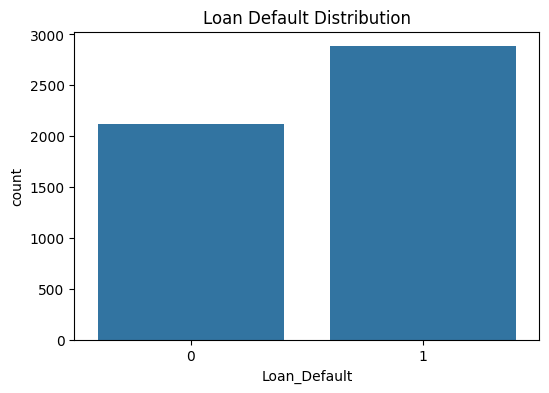

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Default', data=df)
plt.title("Loan Default Distribution")
plt.show()

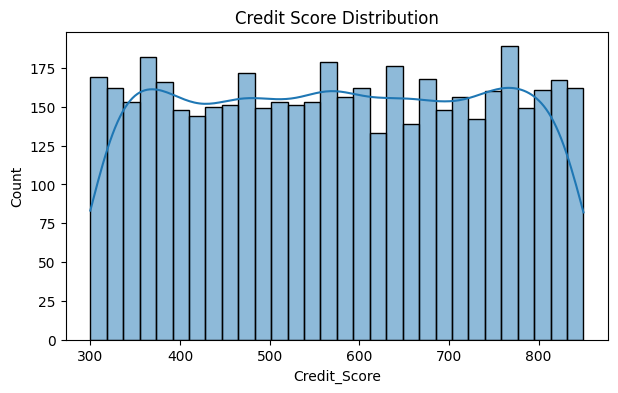

In [6]:
plt.figure(figsize=(7,4))
sns.histplot(df["Credit_Score"], bins=30, kde=True)
plt.title("Credit Score Distribution")
plt.show()

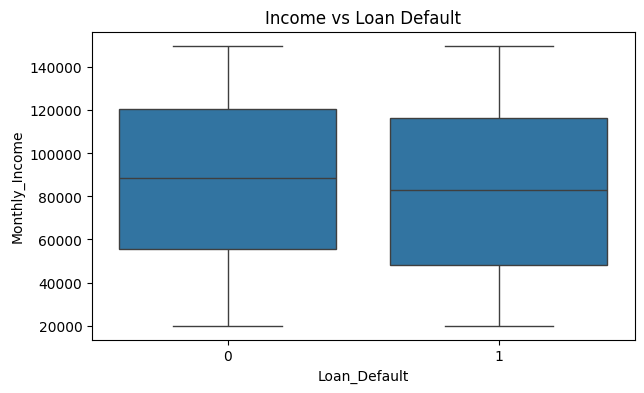

In [7]:
plt.figure(figsize=(7,4))
sns.boxplot(x="Loan_Default", y="Monthly_Income", data=df)
plt.title("Income vs Loan Default")
plt.show()

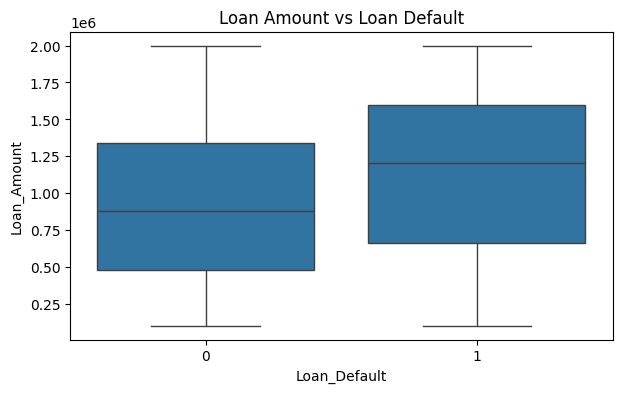

In [8]:
plt.figure(figsize=(7,4))
sns.boxplot(x="Loan_Default", y="Loan_Amount", data=df)
plt.title("Loan Amount vs Loan Default")
plt.show()

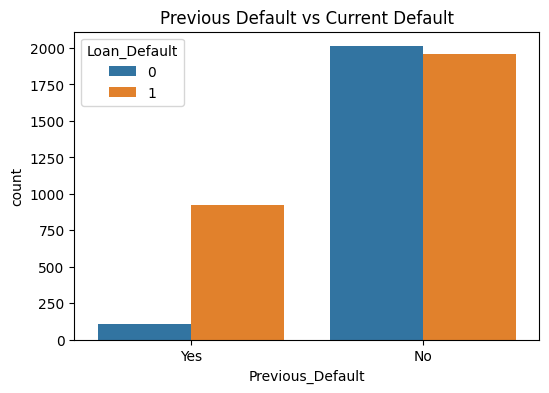

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Previous_Default", hue="Loan_Default", data=df)
plt.title("Previous Default vs Current Default")
plt.show()

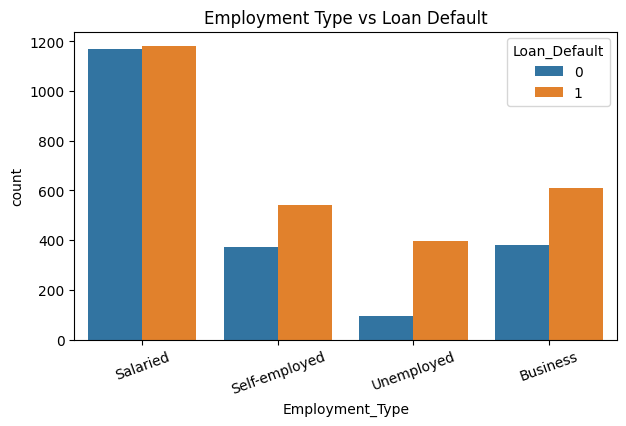

In [10]:
plt.figure(figsize=(7,4))
sns.countplot(x="Employment_Type", hue="Loan_Default", data=df)
plt.xticks(rotation=20)
plt.title("Employment Type vs Loan Default")
plt.show()

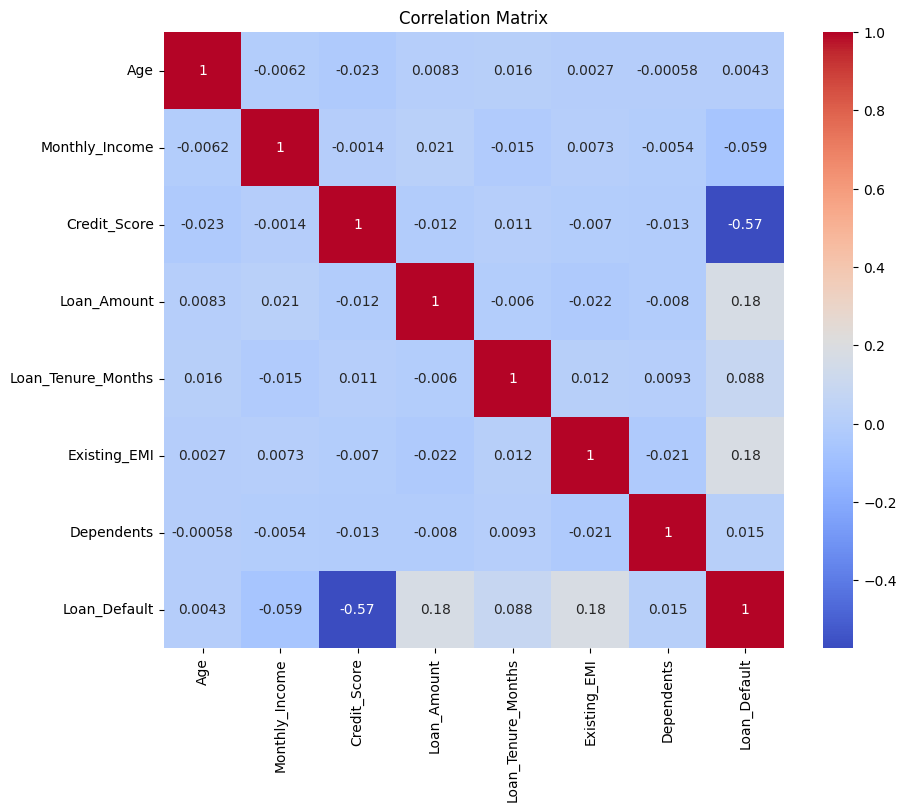

In [11]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [12]:
X = df.drop(columns=["Loan_Default", "Customer_ID"])
y = df["Loan_Default"]

numeric_features = X.select_dtypes(include=['int64','float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing Pipeline Created Successfully")

Preprocessing Pipeline Created Successfully


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4000, 11)
(1000, 11)


In [14]:
dummy_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier())
])

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

dummy_prob = dummy_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,dummy_pred))
print("Precision:", precision_score(y_test,dummy_pred))
print("Recall :", recall_score(y_test,dummy_pred))
print("F1 :", f1_score(y_test,dummy_pred))
print("ROC-AUC :", roc_auc_score(y_test,dummy_prob))

Accuracy : 0.577
Precision: 0.577
Recall : 1.0
F1 : 0.7317691819911224
ROC-AUC : 0.5


In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)

    prob = pipeline.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    f1 = f1_score(y_test,pred)
    roc = roc_auc_score(y_test,prob)

    results.append([name,accuracy,precision,recall,f1,roc])

    print("="*50)
    print(name)
    print(classification_report(y_test,pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       423
           1       0.89      0.90      0.90       577

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000

Decision Tree
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       423
           1       0.89      0.91      0.90       577

    accuracy                           0.89      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.89      0.88      1000

Random Forest
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       423
           1       0.91      0.93      0.92       577

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90   

In [16]:
results_df = pd.DataFrame(results,
                          columns=[
                              "Model",
                              "Accuracy",
                              "Precision",
                              "Recall",
                              "F1-Score",
                              "ROC-AUC"
                          ])

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.881,0.894828,0.899480,0.897148,0.952633
1,Decision Tree,0.885,0.894198,0.908146,0.901118,0.880787
2,Random Forest,0.903,0.906780,0.927210,0.916881,0.973073
3,Gradient Boosting,0.906,0.925926,0.909879,0.917832,0.977359


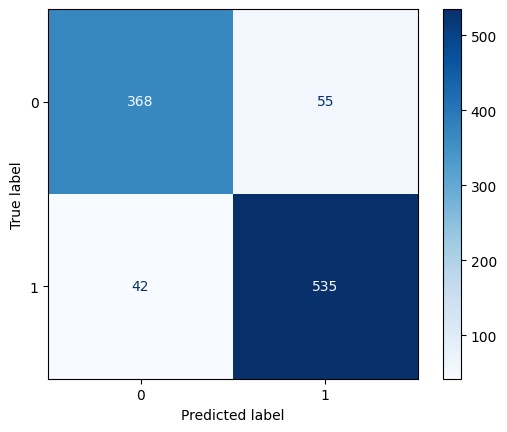

In [17]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train,y_train)

rf_pred = rf_pipeline.predict(X_test)

cm = confusion_matrix(y_test,rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.show()

In [18]:
print(results_df)

best_model = results_df.sort_values("ROC-AUC", ascending=False)

print("\nBest Model Based on ROC-AUC")

display(best_model)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression     0.881   0.894828  0.899480  0.897148  0.952633
1        Decision Tree     0.885   0.894198  0.908146  0.901118  0.880787
2        Random Forest     0.903   0.906780  0.927210  0.916881  0.973073
3    Gradient Boosting     0.906   0.925926  0.909879  0.917832  0.977359

Best Model Based on ROC-AUC


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Gradient Boosting,0.906,0.925926,0.909879,0.917832,0.977359
2,Random Forest,0.903,0.906780,0.927210,0.916881,0.973073
0,Logistic Regression,0.881,0.894828,0.899480,0.897148,0.952633
1,Decision Tree,0.885,0.894198,0.908146,0.901118,0.880787


In [19]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid = {

    "classifier__n_estimators":[50,100,200],

    "classifier__max_depth":[5,10,15],

    "classifier__min_samples_split":[2,5,10],

    "classifier__class_weight":[None,"balanced"]

}

grid = GridSearchCV(

    rf_pipeline,

    param_grid,

    cv=5,

    scoring="roc_auc",

    n_jobs=-1

)

grid.fit(X_train,y_train)

print("Best Parameters")

print(grid.best_params_)

print("Best ROC-AUC")

print(grid.best_score_)

Best Parameters
{'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best ROC-AUC
0.9645645578155333


,Feature,Importance
2,num__Credit_Score,0.473463
5,num__Existing_EMI,0.089119
3,num__Loan_Amount,0.085160
17,cat__Previous_Default_No,0.084463
18,cat__Previous_Default_Yes,0.072909
1,num__Monthly_Income,0.050722
0,num__Age,0.030520
4,num__Loan_Tenure_Months,0.025968
10,cat__Employment_Type_Unemployed,0.022416
8,cat__Employment_Type_Salaried,0.015586


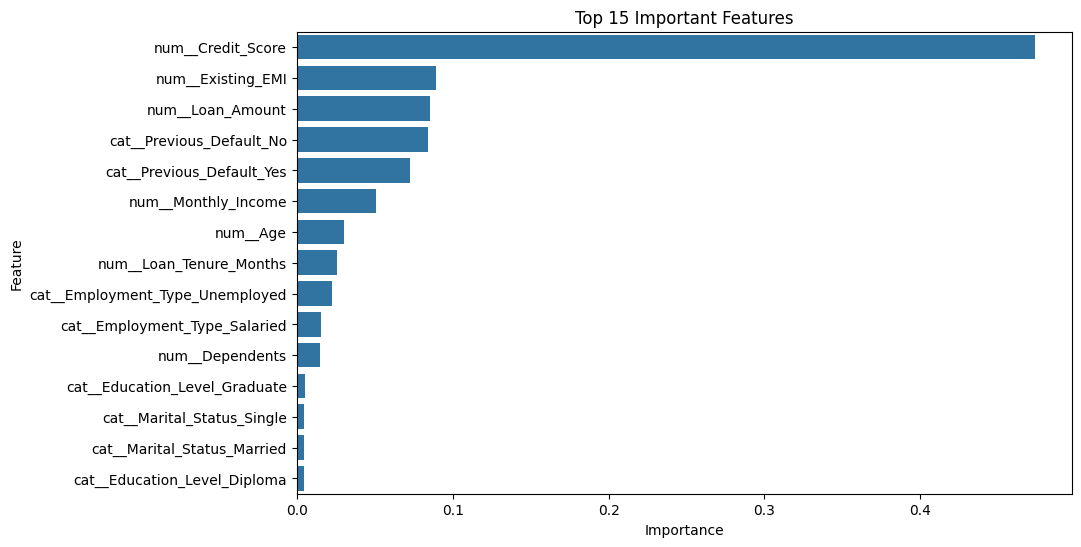

In [20]:
best_rf = grid.best_estimator_

feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

importances = best_rf.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":importances

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df.head(15))

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [21]:
new_customer = pd.DataFrame({

    "Age":[35],

    "Monthly_Income":[40000],

    "Credit_Score":[590],

    "Loan_Amount":[800000],

    "Loan_Tenure_Months":[48],

    "Existing_EMI":[12000],

    "Employment_Type":["Self-employed"],

    "Education_Level":["Graduate"],

    "Marital_Status":["Married"],

    "Dependents":[2],

    "Previous_Default":["Yes"]

})

prediction = best_rf.predict(new_customer)

probability = best_rf.predict_proba(new_customer)

print("Prediction :", prediction[0])

print("Probability :", probability)

if prediction[0]==1:
    print("Loan Default Risk : HIGH")
else:
    print("Loan Default Risk : LOW")

Prediction : 1
Probability : [[0.11775473 0.88224527]]
Loan Default Risk : HIGH
